# Introduction

This project analyzes a Portuguese banking institution’s direct marketing campaign data.
The objective is to build a predictive model that helps the bank identify customers who are likely to subscribe to a term deposit.

The goal is not only to build a machine learning model but also to provide business insights that help improve marketing efficiency and reduce operational cost

In [1]:
# First, install the xgboost package
!pip install xgboost

# Basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# XGBoost - now it will work after installation
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("bank-additional-full.csv", sep=";")
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
df.shape

(41188, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [5]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [6]:
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

# Exploratory Data Analysis (EDA)

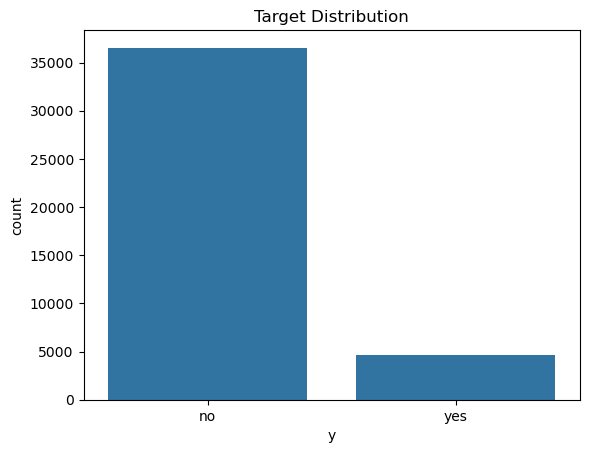

y
no     88.734583
yes    11.265417
Name: proportion, dtype: float64

In [7]:
sns.countplot(x='y', data=df)
plt.title("Target Distribution")
plt.show()

df['y'].value_counts(normalize=True)*100

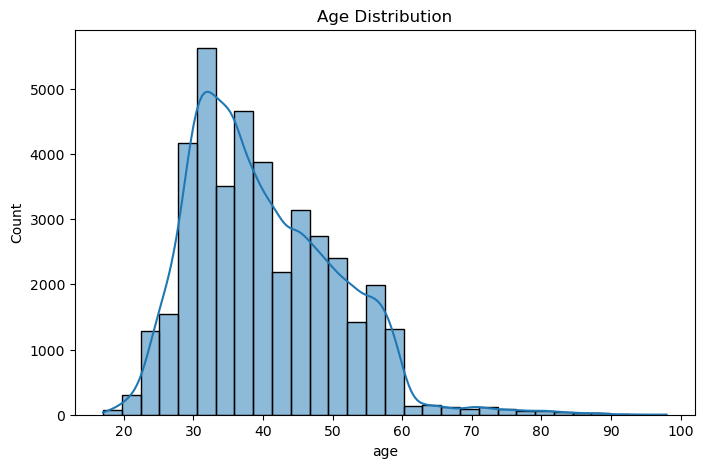

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

In [9]:
pd.crosstab(df['contact'], df['y'], normalize='index')*100

y,no,yes
contact,,
cellular,85.262393,14.737607
telephone,94.768679,5.231321


In [10]:
pd.crosstab(df['poutcome'], df['y'], normalize='index')*100

y,no,yes
poutcome,,
failure,85.771402,14.228598
nonexistent,91.167787,8.832213
success,34.887109,65.112891


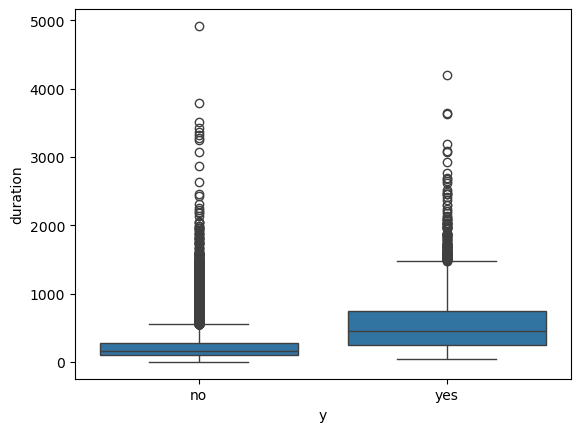

In [11]:
sns.boxplot(x='y', y='duration', data=df)
plt.show()

# Data Preprocessing

In [12]:
df.drop("duration", axis=1, inplace=True)

In [13]:
df['y'] = df['y'].map({'yes':1, 'no':0})

One Hot Encoding

In [14]:
df = pd.get_dummies(df, drop_first=True)
df.head()

,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,56,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0,...,True,False,False,False,True,False,False,False,True,False
1,57,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0,...,True,False,False,False,True,False,False,False,True,False
2,37,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0,...,True,False,False,False,True,False,False,False,True,False
3,40,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0,...,True,False,False,False,True,False,False,False,True,False
4,56,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0,...,True,False,False,False,True,False,False,False,True,False


In [15]:
X = df.drop("y", axis=1)
y = df["y"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

In [16]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model Building

1. Logistic Regression

In [17]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:,1]))

              precision    recall  f1-score   support

           0       0.91      0.99      0.95     10965
           1       0.69      0.22      0.34      1392

    accuracy                           0.90     12357
   macro avg       0.80      0.60      0.64     12357
weighted avg       0.88      0.90      0.88     12357

ROC-AUC: 0.8034924996462098


2. Decision Tree

In [18]:
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print(classification_report(y_test, y_pred_dt))
print("ROC-AUC:", roc_auc_score(y_test, dt.predict_proba(X_test)[:,1]))

              precision    recall  f1-score   support

           0       0.91      0.98      0.95     10965
           1       0.65      0.26      0.37      1392

    accuracy                           0.90     12357
   macro avg       0.78      0.62      0.66     12357
weighted avg       0.88      0.90      0.88     12357

ROC-AUC: 0.7892679030981546


3. Random Forest

In [19]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))

              precision    recall  f1-score   support

           0       0.91      0.97      0.94     10965
           1       0.57      0.28      0.38      1392

    accuracy                           0.89     12357
   macro avg       0.74      0.63      0.66     12357
weighted avg       0.88      0.89      0.88     12357

ROC-AUC: 0.7799438259666335


4. Gradient Boosting

In [20]:
gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

print(classification_report(y_test, y_pred_gb))
print("ROC-AUC:", roc_auc_score(y_test, gb.predict_proba(X_test)[:,1]))

              precision    recall  f1-score   support

           0       0.91      0.99      0.95     10965
           1       0.68      0.23      0.34      1392

    accuracy                           0.90     12357
   macro avg       0.80      0.61      0.65     12357
weighted avg       0.88      0.90      0.88     12357

ROC-AUC: 0.8084658736523211


5. XGBoost

In [21]:
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1]))

              precision    recall  f1-score   support

           0       0.91      0.98      0.95     10965
           1       0.63      0.28      0.39      1392

    accuracy                           0.90     12357
   macro avg       0.77      0.63      0.67     12357
weighted avg       0.88      0.90      0.88     12357

ROC-AUC: 0.7946525582967751


# Model Comparison

In [22]:
models = {
    "Logistic": lr,
    "Decision Tree": dt,
    "Random Forest": rf,
    "Gradient Boosting": gb,
    "XGBoost": xgb
}

results = []

for name, model in models.items():
    if name == "Logistic":
        auc = roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:,1])
    else:
        auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
    results.append([name, auc])

pd.DataFrame(results, columns=["Model", "ROC-AUC"]).sort_values(by="ROC-AUC", ascending=False)

,Model,ROC-AUC
3,Gradient Boosting,0.808466
0,Logistic,0.803492
4,XGBoost,0.794653
1,Decision Tree,0.789268
2,Random Forest,0.779944


# SMOTE

In [23]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

# Split first
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply SMOTE only on training data
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

# Train model
from sklearn.ensemble import GradientBoostingClassifier
model = GradientBoostingClassifier()
model.fit(X_train_res, y_train_res)

# Predict
y_pred = model.predict(X_test)
y_probs = model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_probs))

              precision    recall  f1-score   support

           0       0.93      0.91      0.92      7303
           1       0.41      0.49      0.45       935

    accuracy                           0.86      8238
   macro avg       0.67      0.70      0.69      8238
weighted avg       0.87      0.86      0.87      8238

ROC-AUC: 0.7635832025663762


In [24]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_probs = model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_probs))

              precision    recall  f1-score   support

           0       0.94      0.85      0.90      7303
           1       0.35      0.61      0.44       935

    accuracy                           0.83      8238
   macro avg       0.65      0.73      0.67      8238
weighted avg       0.88      0.83      0.84      8238

ROC-AUC: 0.7818430049624321


# Random Forest with Class Weight

In [25]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# Threshold Tuning

In [26]:
# Train normal model first
model = GradientBoostingClassifier()
model.fit(X_train, y_train)

# Get probabilities
y_probs = model.predict_proba(X_test)[:,1]

# Change threshold
import numpy as np
y_pred_new = np.where(y_probs > 0.30, 1, 0)

print(classification_report(y_test, y_pred_new))
print("ROC-AUC:", roc_auc_score(y_test, y_probs))

              precision    recall  f1-score   support

           0       0.93      0.94      0.93      7303
           1       0.48      0.46      0.47       935

    accuracy                           0.88      8238
   macro avg       0.71      0.70      0.70      8238
weighted avg       0.88      0.88      0.88      8238

ROC-AUC: 0.7892212635492996


## Note
The ‘duration’ feature was removed to prevent data leakage, as it is only known after the call ends. Since the objective is to predict subscription before calling the customer, duration cannot be used.

## Accuracy ≈ 0.90

## Recall (Yes) ≈ 0.25–0.30

## ROC-AUC ≈ 0.80

Since the dataset is imbalanced, accuracy is not a reliable metric. Therefore, ROC-AUC and Recall were used to evaluate model performance.

# Model	           ROC-AUC
Gradient Boosting  0.808

Logistic	       0.803

XGBoost	           0.795 

Gradient Boosting is selected as the production model because it achieved the highest ROC-AUC score (0.808), indicating better discrimination ability between subscribers and non-subscribers.

# Challenges Faced

Highly imbalanced dataset

Large number of categorical variables

Data leakage issue with duration

Choosing correct evaluation metric

Balancing recall and precision

# Conclusion

The developed predictive model successfully identifies customers likely to subscribe to term deposits.

Gradient Boosting performed best with ROC-AUC of 0.808.

After removing the duration feature, the model provides realistic and production-ready predictions.

This solution enables the bank to implement data-driven marketing strategies, improve conversion rates, and reduce campaign costs